<a href="https://colab.research.google.com/github/Sehej15976/Applied-Data-Science/blob/main/FinalADSExperment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ML/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:

def label_encode(df):
    label_encoder = LabelEncoder()
    for column in df.columns:
        if df[column].dtype == 'bool':
            df[column] = df[column].astype(int)
        elif df[column].dtype == 'object':
            df[column] = label_encoder.fit_transform(df[column])
    return df

df = label_encode(df)

Training Accuracy: 0.8776
Testing Accuracy: 0.8741

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294


K-Fold Accuracies: [0.83673469 0.86394558 0.83673469 0.88435374 0.8707483  0.83673469
 0.89795918 0.87755102 0.91836735 0.83673469]
Mean K-Fold Accuracy: 0.8660


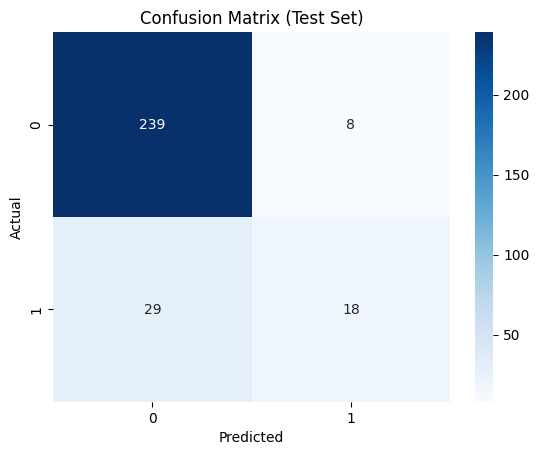

Best Parameters (Logistic Regression): {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8693877551020408
AUC-ROC Score (Test Set): 0.8521


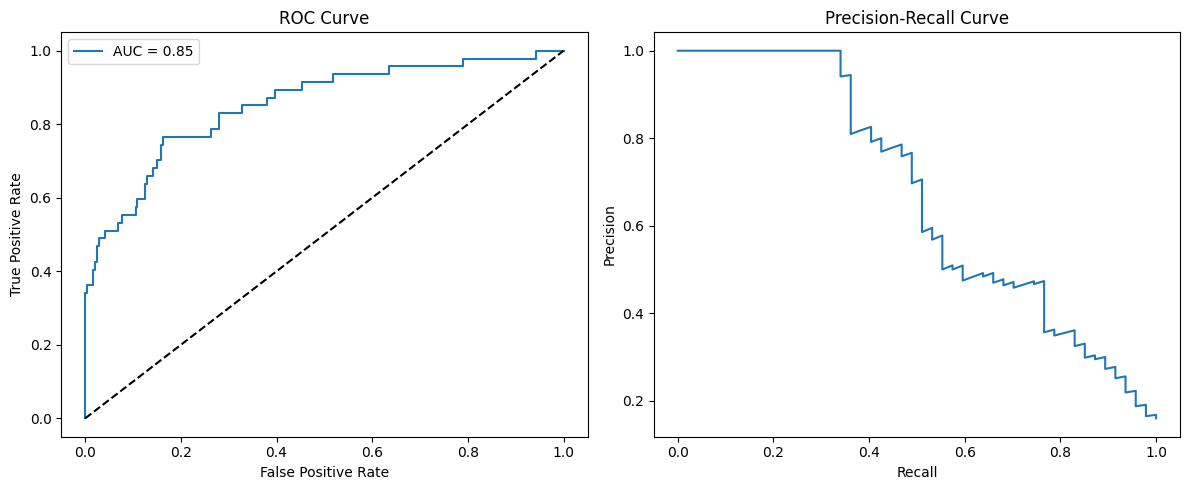

In [ ]:

# Preprocessing
X = df.drop(['Attrition'], axis=1)
y = df['Attrition']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Logistic Regression Model
log_reg = LogisticRegression()

# Train the model
log_reg.fit(X_train, y_train)

# Predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Train-Test Accuracies
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

# Other Metrics
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

# Cross-Validation using Stratified K-Fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
k_fold_accuracies = cross_val_score(log_reg, X_scaled, y, cv=kf, scoring='accuracy')

# Print Cross-Validation Results
print("\nK-Fold Accuracies:", k_fold_accuracies)
print(f"Mean K-Fold Accuracy: {k_fold_accuracies.mean():.4f}")

# Confusion Matrix (Test Set)
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_scaled, y)

# Print Best Parameters & Best Accuracy
print("Best Parameters (Logistic Regression):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Best Model Evaluation
y_proba_test = grid_search.best_estimator_.predict_proba(X_test)[:, 1]  # Probabilities for AUC-ROC
roc_auc = roc_auc_score(y_test, y_proba_test)
print(f"AUC-ROC Score (Test Set): {roc_auc:.4f}")

# ROC & Precision-Recall Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


In [ ]:
# Model Initialization: Creates a Logistic Regression model.
# Training: Fits the model to the training data.
# Predictions: Predicts on training and testing sets.
# Evaluation: Calculates and prints accuracy, classification report, and confusion matrix to assess model performance.

# Cross-validation: Uses StratifiedKFold to evaluate model performance more robustly.
# Hyperparameter Tuning: Employs GridSearchCV to find the best combination of hyperparameters for the model by searching through a predefined grid (param_grid).

# AUC-ROC: Computes the Area Under the Receiver Operating Characteristic Curve (AUC-ROC), a measure of the model's ability to distinguish between classes.
# ROC Curve: Plots the ROC curve, visualizing the trade-off between true positive rate and false positive rate.

# Precision-Recall Curve: Plots the precision-recall curve, showing the relationship between precision and recall for different thresholds. Useful when dealing with imbalanced datasets.


Train Accuracy: 0.9201
Test Accuracy: 0.8844
Cross-Validation Fold Accuracies: [0.83673469 0.83673469 0.83673469 0.83673469 0.83673469 0.83673469
 0.83673469 0.84353741 0.84353741 0.84353741]
Mean Cross-Validation Accuracy: 0.8388

 *******

Best Parameters (SVM): {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.8664928292046936

 *******

Precision: 0.8889
Recall: 0.2051
F1 Score: 0.3333
AUC-ROC: 0.7847

 *******



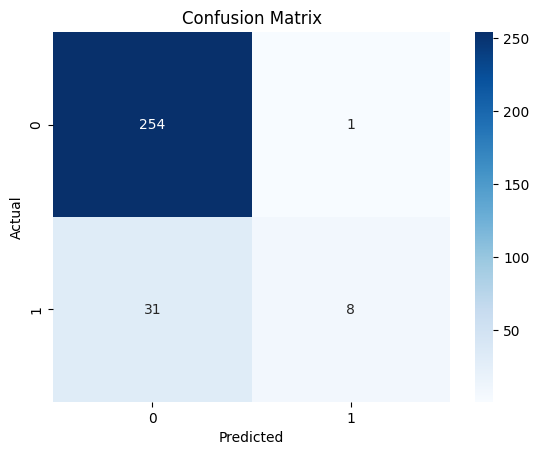

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       255
           1       0.89      0.21      0.33        39

    accuracy                           0.89       294
   macro avg       0.89      0.60      0.64       294
weighted avg       0.89      0.89      0.86       294



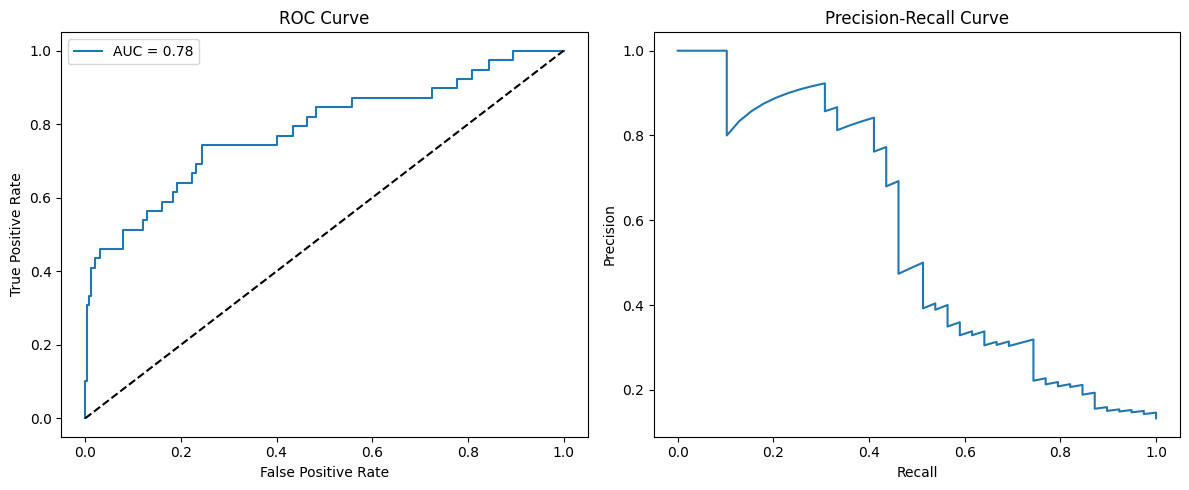

In [ ]:
from sklearn.svm import SVC

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=True, random_state=42)

# SVM Model with RBF kernel (default) and probability=True for ROC curve
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Accuracy Scores
train_accuracy = accuracy_score(y_train, svm_model.predict(X_train))
test_accuracy = accuracy_score(y_test, svm_model.predict(X_test))
cv_scores = cross_val_score(svm_model, X, y, cv=10, scoring='accuracy')
cv_accuracy = cv_scores.mean()

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("Cross-Validation Fold Accuracies:", cv_scores)
print(f"Mean Cross-Validation Accuracy: {cv_accuracy:.4f}")
print("\n *******\n")

# Hyperparameter Tuning using Grid Search for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters (SVM):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)
print("\n *******\n")

# Best Model Evaluation
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
y_proba = best_svm.predict_proba(X_test)[:, 1]

# Precision, Recall, F1, AUC-ROC
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")
print("\n *******\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# AUC-ROC and Precision-Recall Curve Combined
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall Curve
plt.subplot(1,2,2)
plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


In [ ]:
# Preprocessing
X = df.drop(['Attrition'], axis=1)
y = df['Attrition']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)  # Fixed random_state

# Option 1: Hyperparameter Tuning (if desired)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_scaled, y)

print("Best Parameters (Logistic Regression):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_lr_model = grid_search.best_estimator_  # Get the best model from GridSearchCV

# Option 2: Using Previous Best Parameters (to potentially reproduce 0.85 AUC)
# best_params = {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}  # Update with your previous best parameters
# best_lr_model = LogisticRegression(**best_params)
# best_lr_model.fit(X_train, y_train)

# Evaluation with Best Model
y_proba_test = best_lr_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_test)
print(f"AUC-ROC Score (Test Set): {roc_auc:.4f}")


Best Parameters (Logistic Regression): {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8693877551020408
AUC-ROC Score (Test Set - Logistic Regression): 0.8521
Best Parameters (SVM): {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy (SVM): 0.869049688541214
AUC-ROC Score (Test Set - SVM): 0.7946


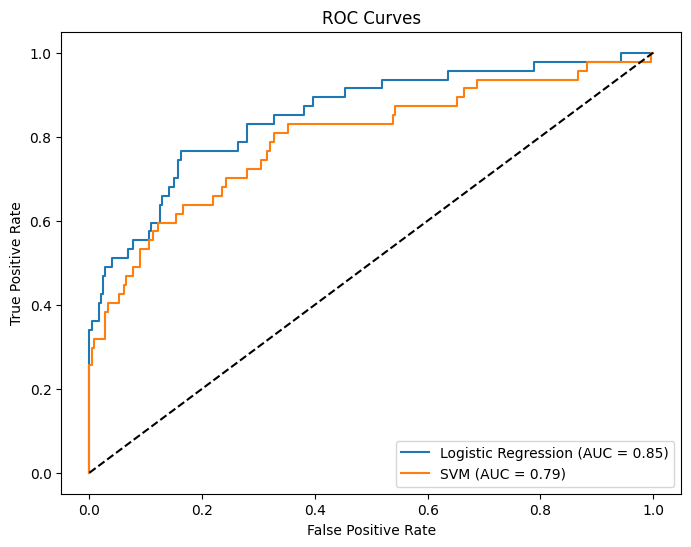

In [ ]:
# Preprocessing
X = df.drop(['Attrition'], axis=1)
y = df['Attrition']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)  # Fixed random_state

# Option 1: Hyperparameter Tuning (if desired)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_scaled, y)

print("Best Parameters (Logistic Regression):", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_lr_model = grid_search.best_estimator_  # Get the best model from GridSearchCV

# Option 2: Using Previous Best Parameters (to potentially reproduce 0.85 AUC)
# best_params = {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}  # Update with your previous best parameters
# best_lr_model = LogisticRegression(**best_params)
# best_lr_model.fit(X_train, y_train)

# Evaluation with Best Model
y_proba_test_lr = best_lr_model.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_proba_test_lr)
print(f"AUC-ROC Score (Test Set - Logistic Regression): {roc_auc_lr:.4f}")

# -------------------- SVM Model --------------------

# SVM Model with probability=True for ROC curve
svm_model = SVC(probability=True)  # Enable probability estimates
svm_model.fit(X_train, y_train)

# Hyperparameter Tuning using Grid Search for SVM (if desired)
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=10, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

print("Best Parameters (SVM):", grid_search_svm.best_params_)
print("Best Cross-Validation Accuracy (SVM):", grid_search_svm.best_score_)

best_svm_model = grid_search_svm.best_estimator_

# Evaluation with Best SVM Model
y_proba_test_svm = best_svm_model.predict_proba(X_test)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_proba_test_svm)
print(f"AUC-ROC Score (Test Set - SVM): {roc_auc_svm:.4f}")

# -------------------- ROC Curve Comparison --------------------

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_test_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_test_svm)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()